# Policy Iteration Grid World

This notebook is the **hands-on companion** to your Manim video on **Policy Iteration**.

Instead of only showing the final answer, it breaks the full process into small runnable steps so a student can:

- run **Policy Evaluation** one step at a time
- check the **Value Table** after each step
- see which policy arrows change during **Policy Improvement**
- inspect the four action values at a single state using `q = r + \gamma V(s')`
- run the agent on the current or final policy and verify whether it reaches the Goal

---

## How to use this notebook

The best learning flow is:

1. Watch the video once.
2. Open this notebook.
3. Run the cells **from top to bottom**.
4. Pause after each visualization and ask:  
   **“Why did this value change?”**  
   **“Why did this arrow change?”**


## How this notebook matches the video

This notebook stays as close as possible to the video setup:

- **5×5 Grid World**
- discount factor `\gamma = 0.9`
- fixed policy-evaluation schedule:
  - Iteration 1: `k = 10`
  - Iteration 2 and later: `k = 5`
- random initial policy with `seed = 42`
- **deterministic transitions**
- if the agent hits a wall, it stays in the same cell and uses that cell's reward/value
- **only the Goal `(4,4)` is treated as a non-updating terminal state**
- important: in the video code, a `-1.0` Trap is **not terminal**; it is just a high-penalty cell

So this notebook is best understood as:

> **Policy Iteration / Modified Policy Iteration with fixed `k` evaluation steps**

rather than “fully evaluate the value function to convergence in every outer iteration.”


In [1]:
# Run this cell first
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

np.set_printoptions(suppress=True)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)


## 1. Main explorer class

The class below packages the video logic into an interactive tool called `PolicyIterationExplorer`.

These are the methods you will use the most:

- `demo.render()` → draw the grid, values, policy arrows, and error chart
- `demo.show_tables()` → show the value table, policy table, and iteration summary
- `demo.begin_iteration()` → start a new outer policy-iteration round
- `demo.evaluation_step()` → run **one** synchronous policy-evaluation sweep
- `demo.evaluation_k_steps()` → keep going until the current round reaches its scheduled `k` steps
- `demo.improve_policy()` → run one greedy policy-improvement step
- `demo.inspect_state((r, c))` → inspect all four action values at one state
- `demo.run_to_convergence()` → automatically run until the policy becomes stable
- `demo.plot_agent_run()` → run the agent on the current policy, with a warning if the policy has not converged yet

Read the code if you want, but you do **not** need to understand every line before using it.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ARROW_SYMBOLS = {0: "↑", 1: "↓", 2: "←", 3: "→", -1: "·"}
ACTION_NAMES = {0: "Up", 1: "Down", 2: "Left", 3: "Right", -1: "Goal"}

class PolicyIterationExplorer:
    """
    A teaching-friendly Policy Iteration explorer that matches the video setup:

    - 5x5 Grid World
    - fixed-k policy evaluation (10 steps in round 1, then 5 steps)
    - random initial policy with seed=42
    - the goal state (4, 4) is treated as a non-updating terminal state
    """

    def __init__(self, gamma=0.9, seed=42, pe_steps_schedule=None):
        self.gamma = gamma
        self.seed = seed
        self.grid_size = 5
        self.goal_state = (4, 4)
        self.actions = [(-1, 0), (1, 0), (0, -1), (0, 1)]
        self.pe_steps_schedule = pe_steps_schedule or [10, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]

        self.rewards = np.array([
            [-0.04, -0.04, -0.04, -0.50, -1.00],
            [-0.04, -1.00, -0.04, -1.00, -1.00],
            [-0.04, -0.50, -0.04, -0.04, -0.04],
            [-1.00, -1.00, -1.00, -1.00, -0.04],
            [-1.00, -0.04, -0.04, -0.04,  1.00]
        ], dtype=float)

        self.reset(seed=seed)

    def reset(self, seed=None):
        if seed is not None:
            self.seed = seed

        rng = np.random.RandomState(self.seed)  # match the video behavior
        self.values = np.zeros((self.grid_size, self.grid_size), dtype=float)
        self.policy = rng.randint(0, 4, size=(self.grid_size, self.grid_size))
        self.policy[self.goal_state] = -1

        self.outer_iter = 0
        self.current_eval_step = 0
        self.current_target_steps = None
        self.current_phase = "Initialization"
        self.current_eval_errors = []
        self.iteration_summaries = []
        self.last_changed_states = []
        self.policy_stable = False

    def _in_bounds(self, r, c):
        return 0 <= r < self.grid_size and 0 <= c < self.grid_size

    def _transition(self, r, c, action_idx, values_snapshot=None):
        if values_snapshot is None:
            values_snapshot = self.values

        if (r, c) == self.goal_state:
            return {
                "next_state": (r, c),
                "reward": self.rewards[r, c],
                "next_value": values_snapshot[r, c],
                "q": values_snapshot[r, c],
                "hit_wall": False,
            }

        dr, dc = self.actions[action_idx]
        nr, nc = r + dr, c + dc

        if self._in_bounds(nr, nc):
            reward = float(self.rewards[nr, nc])
            next_value = float(values_snapshot[nr, nc])
            hit_wall = False
        else:
            nr, nc = r, c
            reward = float(self.rewards[r, c])
            next_value = float(values_snapshot[r, c])
            hit_wall = True

        q = reward + self.gamma * next_value
        return {
            "next_state": (nr, nc),
            "reward": reward,
            "next_value": next_value,
            "q": float(q),
            "hit_wall": hit_wall,
        }

    def begin_iteration(self):
        self.outer_iter += 1
        schedule_idx = min(self.outer_iter - 1, len(self.pe_steps_schedule) - 1)
        self.current_target_steps = int(self.pe_steps_schedule[schedule_idx])
        self.current_eval_step = 0
        self.current_eval_errors = []
        self.last_changed_states = []
        self.current_phase = "Policy Evaluation"
        print(
            f"Starting outer iteration {self.outer_iter}. "
            f"This round will use a fixed evaluation budget of k = {self.current_target_steps}."
        )

    def evaluation_step(self, verbose=True):
        if self.current_target_steps is None:
            self.begin_iteration()

        if self.current_eval_step >= self.current_target_steps:
            print("The scheduled evaluation steps for this round are already complete. You can now run demo.improve_policy().")
            return None

        old_values = self.values.copy()
        new_values = old_values.copy()
        logs = []

        for r in range(self.grid_size):
            for c in range(self.grid_size):
                if (r, c) == self.goal_state:
                    continue

                action_idx = int(self.policy[r, c])
                info = self._transition(r, c, action_idx, old_values)
                new_values[r, c] = info["q"]
                diff = abs(new_values[r, c] - old_values[r, c])

                logs.append({
                    "state": (r, c),
                    "old_v": float(old_values[r, c]),
                    "new_v": float(new_values[r, c]),
                    "diff": float(diff),
                    "action": ARROW_SYMBOLS[action_idx],
                    "next_state": info["next_state"],
                    "reward": info["reward"],
                })

        self.values = new_values
        self.current_eval_step += 1
        self.current_phase = "Policy Evaluation"

        max_diff = max(row["diff"] for row in logs) if logs else 0.0
        self.current_eval_errors.append(max(max_diff, 1e-12))

        if verbose:
            print(
                f"Outer iteration {self.outer_iter} | "
                f"Evaluation step {self.current_eval_step}/{self.current_target_steps}"
            )
            print(f"Maximum value change in this step: max_diff = {max_diff:.6f}")
            df = pd.DataFrame(logs).sort_values("diff", ascending=False).head(8)
            display(df)

        return max_diff

    def evaluation_k_steps(self, k=None, verbose=True):
        if self.current_target_steps is None:
            self.begin_iteration()

        remaining = self.current_target_steps - self.current_eval_step
        if remaining <= 0:
            print("Evaluation for the current round is already complete.")
            return

        if k is None:
            k = remaining
        k = min(k, remaining)

        for _ in range(k):
            self.evaluation_step(verbose=verbose)

    def inspect_state(self, state):
        r, c = state
        if not self._in_bounds(r, c):
            raise ValueError("The requested state is outside the grid.")

        rows = []
        for action_idx in range(4):
            info = self._transition(r, c, action_idx, self.values)
            rows.append({
                "action_id": action_idx,
                "action": ACTION_NAMES[action_idx],
                "arrow": ARROW_SYMBOLS[action_idx],
                "next_state": info["next_state"],
                "immediate_reward r": info["reward"],
                "next_state_value V(s')": info["next_value"],
                "q = r + γV(s')": info["q"],
                "hit_wall": info["hit_wall"],
            })

        df = pd.DataFrame(rows).sort_values("q = r + γV(s')", ascending=False).reset_index(drop=True)
        current_action = int(self.policy[r, c]) if (r, c) != self.goal_state else -1
        print(f"Current policy at state {state}: {ACTION_NAMES[current_action]} {ARROW_SYMBOLS[current_action]}")
        display(df)
        return df

    def improve_policy(self, verbose=True):
        if self.current_target_steps is None:
            print("No iteration has started yet. Run demo.begin_iteration() or demo.evaluation_step() first.")
            return None

        self.current_phase = "Policy Improvement"
        changed_states = []
        change_rows = []

        for r in range(self.grid_size):
            for c in range(self.grid_size):
                if (r, c) == self.goal_state:
                    continue

                old_action = int(self.policy[r, c])

                q_values = []
                for action_idx in range(4):
                    info = self._transition(r, c, action_idx, self.values)
                    q_values.append(info["q"])

                best_action = int(np.argmax(q_values))

                if best_action != old_action:
                    self.policy[r, c] = best_action
                    changed_states.append((r, c))
                    change_rows.append({
                        "state": (r, c),
                        "old_action": f"{ACTION_NAMES[old_action]} {ARROW_SYMBOLS[old_action]}",
                        "new_action": f"{ACTION_NAMES[best_action]} {ARROW_SYMBOLS[best_action]}",
                        "q(Up)": q_values[0],
                        "q(Down)": q_values[1],
                        "q(Left)": q_values[2],
                        "q(Right)": q_values[3],
                    })

        self.last_changed_states = changed_states
        self.policy_stable = len(changed_states) == 0

        summary = {
            "iteration": self.outer_iter,
            "k": self.current_target_steps,
            "eval_steps_done": self.current_eval_step,
            "last_max_diff": float(self.current_eval_errors[-1]) if self.current_eval_errors else np.nan,
            "changed_states": len(changed_states),
            "stable": self.policy_stable,
        }
        self.iteration_summaries.append(summary)

        if verbose:
            print(f"Policy improvement for outer iteration {self.outer_iter} is complete.")
            print(f"Policy stable: {self.policy_stable}")
            print(f"Number of changed states: {len(changed_states)}")
            if change_rows:
                display(pd.DataFrame(change_rows))
            else:
                print("No arrows changed in this round, so the policy is now stable.")

        return self.policy_stable

    def values_table(self, decimals=3):
        idx = [f"r{i}" for i in range(self.grid_size)]
        cols = [f"c{j}" for j in range(self.grid_size)]
        return pd.DataFrame(np.round(self.values, decimals), index=idx, columns=cols)

    def policy_table(self):
        table = np.empty((self.grid_size, self.grid_size), dtype=object)
        for r in range(self.grid_size):
            for c in range(self.grid_size):
                if (r, c) == self.goal_state:
                    table[r, c] = "Goal"
                else:
                    table[r, c] = ARROW_SYMBOLS[int(self.policy[r, c])]
        idx = [f"r{i}" for i in range(self.grid_size)]
        cols = [f"c{j}" for j in range(self.grid_size)]
        return pd.DataFrame(table, index=idx, columns=cols)

    def summary_table(self):
        if not self.iteration_summaries:
            return pd.DataFrame(columns=["iteration", "k", "eval_steps_done", "last_max_diff", "changed_states", "stable"])
        return pd.DataFrame(self.iteration_summaries)

    def show_tables(self):
        print("Current Value Table")
        display(self.values_table())
        print("Current Policy Table")
        display(self.policy_table())
        if len(self.iteration_summaries) > 0:
            print("Iteration Summary")
            display(self.summary_table())

    def _cell_facecolor(self, reward):
        if reward == 1.0:
            return "#0f766e"  # teal
        if reward == -1.0:
            return "#7f1d1d"  # maroon
        if reward == -0.5:
            return "#ea580c"  # orange
        return "#374151"      # dark gray

    def render(self, figsize=(14, 6), title=None):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

        # Left panel: grid world
        for r in range(self.grid_size):
            for c in range(self.grid_size):
                reward = float(self.rewards[r, c])
                y = self.grid_size - 1 - r

                rect = plt.Rectangle(
                    (c, y), 1, 1,
                    facecolor=self._cell_facecolor(reward),
                    edgecolor="white", linewidth=2
                )
                ax1.add_patch(rect)

                if reward == 1.0:
                    reward_text = "Goal\n+1.0"
                    reward_color = "yellow"
                elif reward == -1.0:
                    reward_text = "Trap\n-1.0"
                    reward_color = "white"
                elif reward == -0.5:
                    reward_text = "Mud\n-0.5"
                    reward_color = "white"
                else:
                    reward_text = "-0.04"
                    reward_color = "white"

                ax1.text(
                    c + 0.5, y + 0.72, reward_text,
                    ha="center", va="center", fontsize=9, color=reward_color
                )
                ax1.text(
                    c + 0.5, y + 0.28, f"{self.values[r, c]:.3f}",
                    ha="center", va="center", fontsize=11, color="white"
                )

                if (r, c) != self.goal_state:
                    action_idx = int(self.policy[r, c])
                    dr, dc = self.actions[action_idx]
                    dx, dy = dc * 0.28, -dr * 0.28
                    color = "limegreen" if (r, c) in self.last_changed_states else "gold"
                    ax1.arrow(
                        c + 0.5, y + 0.5, dx, dy,
                        width=0.02, head_width=0.15, head_length=0.12,
                        length_includes_head=True, color=color
                    )

        # Start label
        sr, sc = 0, 0
        ax1.text(
            sc + 0.08, self.grid_size - 1 - sr + 0.08, "Start",
            fontsize=10, color="cyan", ha="left", va="bottom"
        )

        ax1.set_xlim(0, self.grid_size)
        ax1.set_ylim(0, self.grid_size)
        ax1.set_aspect("equal")
        ax1.set_xticks(np.arange(self.grid_size) + 0.5)
        ax1.set_xticklabels([f"c{j}" for j in range(self.grid_size)])
        ax1.set_yticks(np.arange(self.grid_size) + 0.5)
        ax1.set_yticklabels([f"r{self.grid_size - 1 - i}" for i in range(self.grid_size)])
        ax1.set_title(title or "Grid World: Values + Policy", fontsize=14)
        ax1.set_facecolor("#111827")

        # Right panel: error plot
        if self.current_eval_errors:
            x = np.arange(1, len(self.current_eval_errors) + 1)
            y = np.maximum(np.array(self.current_eval_errors, dtype=float), 1e-8)
            ax2.plot(x, y, marker="o")
            ax2.scatter([x[-1]], [y[-1]], s=80)
            ax2.set_yscale("log")
            ax2.set_ylim(1e-4, 1)
            ax2.set_xlim(1, max(10, self.current_target_steps or 10))
            ax2.grid(True, alpha=0.3)
        else:
            ax2.text(0.5, 0.5, "Policy evaluation has not started yet.", ha="center", va="center", fontsize=14)
            ax2.set_xlim(0, 10)
            ax2.set_ylim(1e-4, 1)
            ax2.set_yscale("log")
            ax2.grid(True, alpha=0.3)

        ax2.set_title("Max Error (Log Scale)", fontsize=14)
        ax2.set_xlabel("Evaluation Step")
        ax2.set_ylabel("Max Error")

        info_lines = [
            f"Phase: {self.current_phase}",
            f"Outer Iteration: {self.outer_iter}",
            f"k schedule: {self.current_target_steps if self.current_target_steps is not None else '--'}",
            f"Policy Stable: {self.policy_stable}",
            f"Changed States (last improve): {len(self.last_changed_states)}",
        ]
        ax2.text(
            0.02, 0.05, "\n".join(info_lines),
            transform=ax2.transAxes, fontsize=11,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
        )

        plt.tight_layout()
        plt.show()

    def run_one_outer_iteration(self, verbose=True):
        self.begin_iteration()
        self.evaluation_k_steps(verbose=verbose)
        stable = self.improve_policy(verbose=verbose)
        return stable

    def run_to_convergence(self, max_outer=15, verbose=True):
        while (not self.policy_stable) and (self.outer_iter < max_outer):
            stable = self.run_one_outer_iteration(verbose=verbose)
            if stable:
                break

        if self.policy_stable:
            print(f"The policy converged after outer iteration {self.outer_iter}.")
        else:
            print(f"Reached max_outer={max_outer}, and the policy is still not marked as stable.")

        return self.policy_stable


    def simulate_agent(self, start_state=(0, 0), max_steps=20):
        r, c = start_state
        path = [(r, c)]
        total_reward = 0.0
        hit_goal = False
        loop_detected = False
        termination_reason = "max_steps"
        seen_states = {start_state}

        for _ in range(max_steps):
            if (r, c) == self.goal_state:
                hit_goal = True
                termination_reason = "goal"
                break

            action_idx = int(self.policy[r, c])
            info = self._transition(r, c, action_idx, self.values)
            nr, nc = info["next_state"]

            total_reward += info["reward"]
            path.append((nr, nc))
            r, c = nr, nc

            if (r, c) == self.goal_state:
                hit_goal = True
                termination_reason = "goal"
                break

            if (r, c) in seen_states:
                loop_detected = True
                termination_reason = "loop"
                break

            seen_states.add((r, c))

        return {
            "path": path,
            "total_reward": total_reward,
            "hit_goal": hit_goal,
            "steps_used": len(path) - 1,
            "loop_detected": loop_detected,
            "termination_reason": termination_reason,
        }

    def plot_agent_run(self, start_state=(0, 0), max_steps=20, figsize=(7, 7)):
        if not self.policy_stable:
            print("Warning: the policy is not stable yet, so this plot shows the agent on the current policy, not the final policy.")

        result = self.simulate_agent(start_state=start_state, max_steps=max_steps)
        path = result["path"]

        fig, ax = plt.subplots(figsize=figsize)

        for r in range(self.grid_size):
            for c in range(self.grid_size):
                reward = float(self.rewards[r, c])
                y = self.grid_size - 1 - r

                rect = plt.Rectangle(
                    (c, y), 1, 1,
                    facecolor=self._cell_facecolor(reward),
                    edgecolor="white", linewidth=2
                )
                ax.add_patch(rect)

                if reward == 1.0:
                    reward_text = "Goal\n+1.0"
                    reward_color = "yellow"
                elif reward == -1.0:
                    reward_text = "Trap\n-1.0"
                    reward_color = "white"
                elif reward == -0.5:
                    reward_text = "Mud\n-0.5"
                    reward_color = "white"
                else:
                    reward_text = "-0.04"
                    reward_color = "white"

                ax.text(
                    c + 0.5, y + 0.72, reward_text,
                    ha="center", va="center", fontsize=9, color=reward_color
                )
                ax.text(
                    c + 0.5, y + 0.28, f"{self.values[r, c]:.3f}",
                    ha="center", va="center", fontsize=11, color="white"
                )

        xs = [c + 0.5 for (_, c) in path]
        ys = [self.grid_size - 1 - r + 0.5 for (r, _) in path]
        ax.plot(xs, ys, linewidth=3, marker="o")

        start_x, start_y = xs[0], ys[0]
        end_x, end_y = xs[-1], ys[-1]
        same_start_end = (len(xs) > 0) and np.isclose(start_x, end_x) and np.isclose(start_y, end_y)

        ax.scatter([start_x], [start_y], s=120, marker="o", label="Start")
        if same_start_end:
            ax.scatter([end_x + 0.08], [end_y - 0.08], s=140, marker="X", label="End / stopped")
            ax.plot([end_x, end_x + 0.08], [end_y, end_y - 0.08], linestyle="--", linewidth=1)
        else:
            ax.scatter([end_x], [end_y], s=140, marker="X", label="End / stopped")

        for idx, (x, y) in enumerate(zip(xs, ys)):
            ax.text(x, y + 0.12, str(idx), fontsize=9, ha="center")

        ax.set_xlim(0, self.grid_size)
        ax.set_ylim(0, self.grid_size)
        ax.set_aspect("equal")
        ax.set_xticks(np.arange(self.grid_size) + 0.5)
        ax.set_xticklabels([f"c{j}" for j in range(self.grid_size)])
        ax.set_yticks(np.arange(self.grid_size) + 0.5)
        ax.set_yticklabels([f"r{self.grid_size - 1 - i}" for i in range(self.grid_size)])

        run_title = "Agent Run on Final Policy" if self.policy_stable else "Agent Run on Current Policy"
        ax.set_title(run_title)

        status_lines = [
            f"Reached goal: {result['hit_goal']}",
            f"Termination: {result['termination_reason']}",
            f"Steps used: {result['steps_used']}",
        ]
        ax.text(
            0.02, 0.02, "\n".join(status_lines),
            transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
        )

        ax.legend(loc="upper left")
        ax.set_facecolor("#111827")
        plt.tight_layout()
        plt.show()

        print("Agent run result:")
        print(result)
        return result


## 2. Initialize the environment and view the “video starting point”

At this point, we are in the same situation as the beginning of the grid demo in the video:

- all `V(s) = 0`
- the policy arrows are randomly initialized
- no evaluation or improvement has happened yet

Take a moment to look at the grid before moving on.


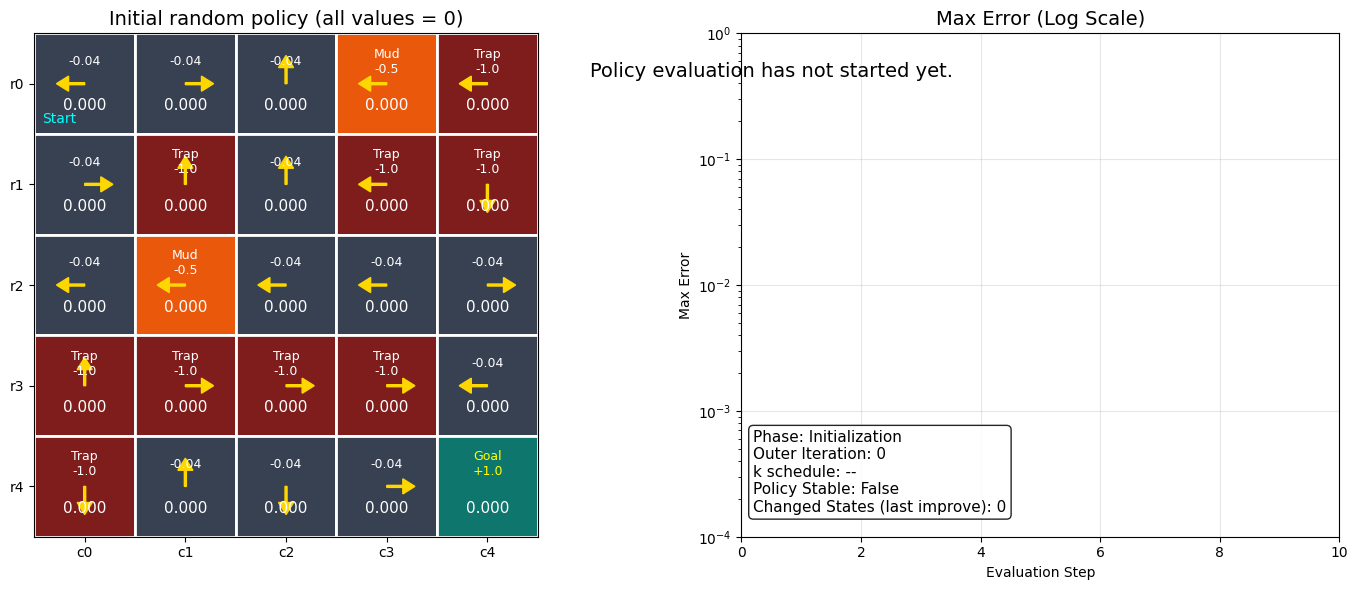

Current Value Table


,c0,c1,c2,c3,c4
r0,0.0,0.0,0.0,0.0,0.0
r1,0.0,0.0,0.0,0.0,0.0
r2,0.0,0.0,0.0,0.0,0.0
r3,0.0,0.0,0.0,0.0,0.0
r4,0.0,0.0,0.0,0.0,0.0


Current Policy Table


,c0,c1,c2,c3,c4
r0,←,→,↑,←,←
r1,→,↑,↑,←,↓
r2,←,←,←,←,→
r3,↑,→,→,→,←
r4,↓,↑,↓,→,Goal


In [3]:

demo = PolicyIterationExplorer(gamma=0.9, seed=42)
demo.render(title="Initial random policy (all values = 0)")
demo.show_tables()


## 3. Manually start outer iteration 1

In the video, the **first outer iteration** is slower because it uses `k = 10`.

Run the next cell and pay attention to the information panel:

- `Phase`
- `Outer Iteration`
- `k schedule`

This tells you what the algorithm is about to do.

If your output does **not** say `outer iteration 1`, the object is not fresh anymore. In that case, rerun the initialization cell above or run `demo.reset(seed=42)` first.


Starting outer iteration 10. This round will use a fixed evaluation budget of k = 5.


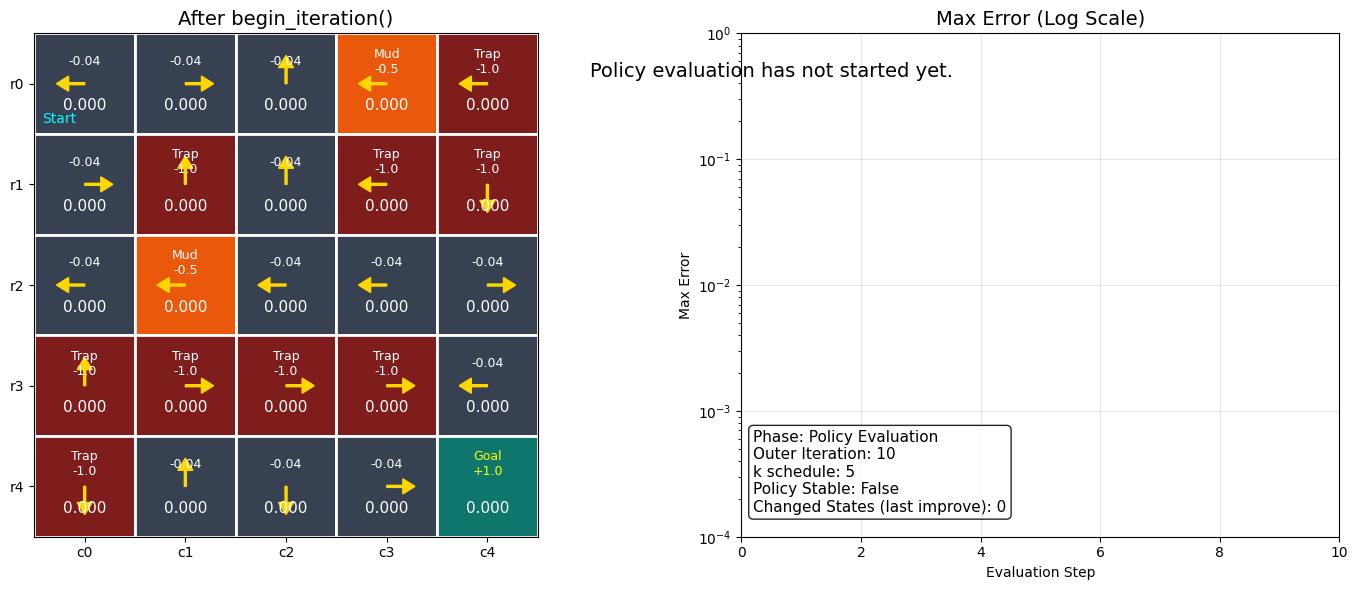

In [13]:

demo.begin_iteration()
demo.render(title="After begin_iteration()")


## 4. Run **one** Policy Evaluation step

This is one of the best cells for teaching.

After a single run, you can immediately see:

- which values start changing
- the `max_diff` for this step
- one new point added to the error chart

You can **run the next cell again and again**.  
Each time you run it, you advance by exactly **one evaluation step**.


The scheduled evaluation steps for this round are already complete. You can now run demo.improve_policy().


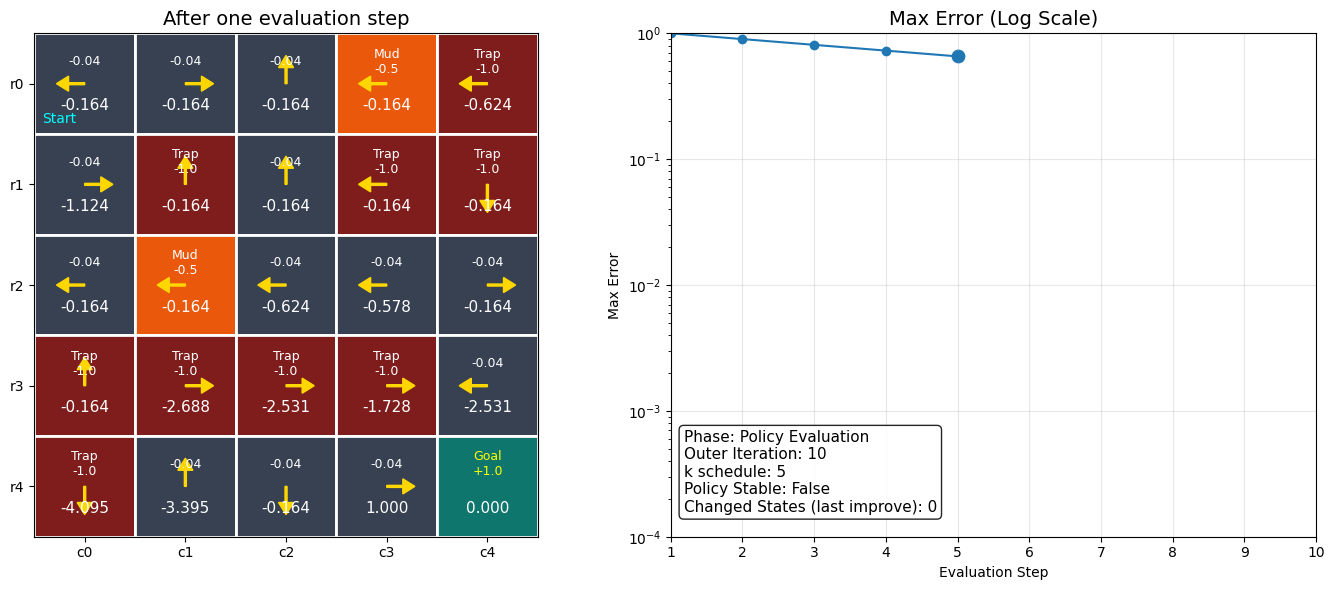

In [22]:

demo.evaluation_step(verbose=True)
demo.render(title="After one evaluation step")


## 5. Finish the remaining evaluation steps for this round

If you already clicked through a few evaluation steps manually, the next cell will only run the **remaining** steps until the current round reaches its target `k`.

For outer iteration 1, the target is `k = 10`.


Evaluation for the current round is already complete.


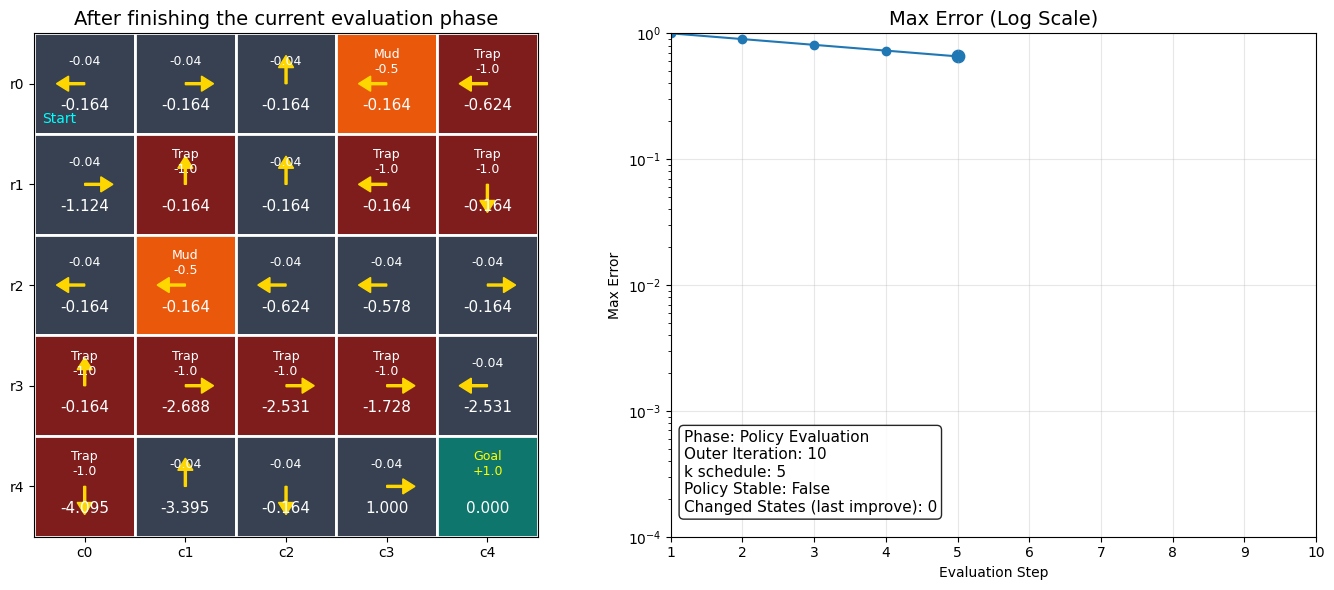

Current Value Table


,c0,c1,c2,c3,c4
r0,-0.164,-0.164,-0.164,-0.164,-0.624
r1,-1.124,-0.164,-0.164,-0.164,-0.164
r2,-0.164,-0.164,-0.624,-0.578,-0.164
r3,-0.164,-2.688,-2.531,-1.728,-2.531
r4,-4.095,-3.395,-0.164,1.000,0.000


Current Policy Table


,c0,c1,c2,c3,c4
r0,←,→,↑,←,←
r1,→,↑,↑,←,↓
r2,←,←,←,←,→
r3,↑,→,→,→,←
r4,↓,↑,↓,→,Goal


In [24]:

demo.evaluation_k_steps(verbose=False)
demo.render(title="After finishing the current evaluation phase")
demo.show_tables()


## 6. Check why one state might change its arrow

`inspect_state((r, c))` shows all four actions from a chosen state:

- next state
- immediate reward `r`
- next-state value `V(s')`
- `q = r + \gamma V(s')`

It also sorts the actions from highest `q` to lowest `q`.

This is a great way to understand the core idea:

> Policy Improvement is just choosing  
> `argmax_a [r + \gamma V(s')]`

In other words: **pick the action with the best one-step lookahead value**.


In [25]:
demo.inspect_state((0, 0))   # You can change this to another state, for example (2, 2) or (3, 4)


Current policy at state (0, 0): Left ←


,action_id,action,arrow,next_state,immediate_reward r,next_state_value V(s'),q = r + γV(s'),hit_wall
0,0,Up,↑,"(0, 0)",-0.04,-0.163804,-0.187424,True
1,2,Left,←,"(0, 0)",-0.04,-0.163804,-0.187424,True
2,3,Right,→,"(0, 1)",-0.04,-0.163804,-0.187424,False
3,1,Down,↓,"(1, 0)",-0.04,-1.123804,-1.051424,False


,action_id,action,arrow,next_state,immediate_reward r,next_state_value V(s'),q = r + γV(s'),hit_wall
0,0,Up,↑,"(0, 0)",-0.04,-0.163804,-0.187424,True
1,2,Left,←,"(0, 0)",-0.04,-0.163804,-0.187424,True
2,3,Right,→,"(0, 1)",-0.04,-0.163804,-0.187424,False
3,1,Down,↓,"(1, 0)",-0.04,-1.123804,-1.051424,False


## 7. Run one Policy Improvement step

This cell tells you:

- how many states changed their arrows
- the old action and new action at each changed state
- the four `q` values used to make that decision

In the plot, **green arrows** mark states whose policy changed during the latest improvement step.


Policy improvement for outer iteration 10 is complete.
Policy stable: False
Number of changed states: 12


,state,old_action,new_action,q(Up),q(Down),q(Left),q(Right)
0,"(0, 0)",Left ←,Up ↑,-0.187424,-1.051424,-0.187424,-0.187424
1,"(0, 1)",Right →,Up ↑,-0.187424,-1.147424,-0.187424,-0.187424
2,"(1, 0)",Right →,Up ↑,-0.187424,-0.187424,-1.051424,-1.147424
3,"(2, 2)",Left ←,Up ↑,-0.187424,-3.278134,-0.647424,-0.560024
4,"(2, 3)",Left ←,Right →,-1.147424,-2.554880,-0.601424,-0.187424
5,"(3, 1)",Right →,Up ↑,-0.647424,-3.095734,-1.147424,-3.278134
6,"(3, 2)",Right →,Down ↓,-0.601424,-0.187424,-3.418880,-2.554880
7,"(3, 3)",Right →,Down ↓,-0.560024,0.860000,-3.278134,-2.318134
8,"(3, 4)",Left ←,Down ↓,-0.187424,1.000000,-2.554880,-2.318134
9,"(4, 0)",Down ↓,Up ↑,-1.147424,-4.685590,-4.685590,-3.095734


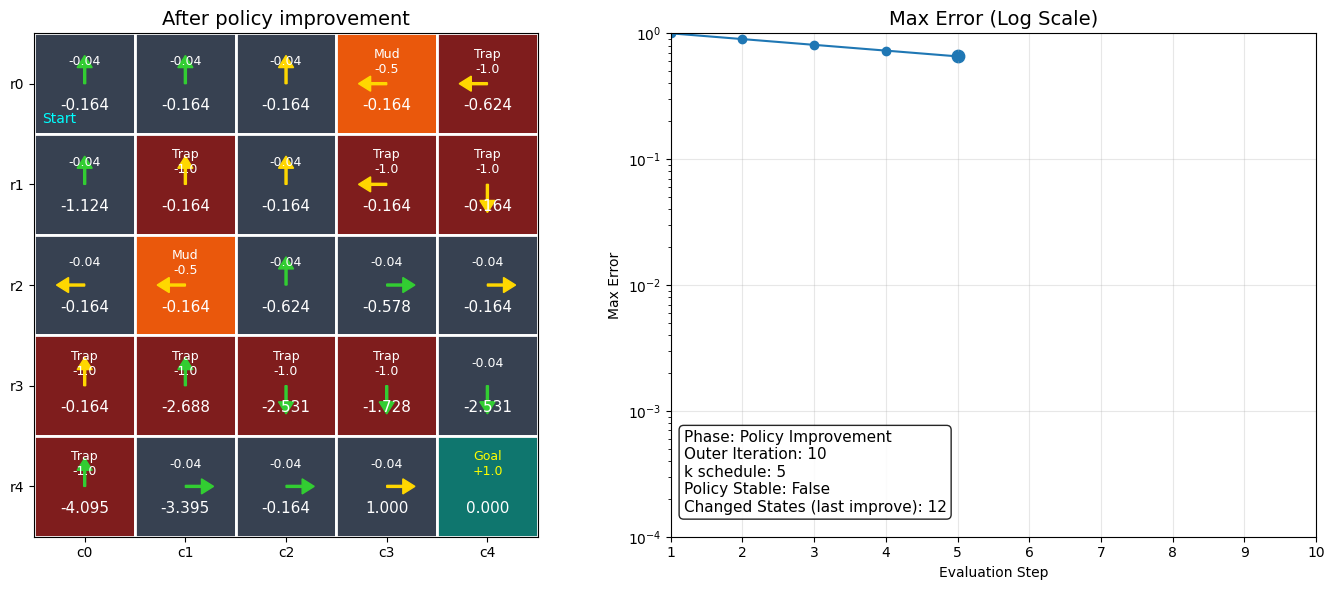

Current Value Table


,c0,c1,c2,c3,c4
r0,-0.164,-0.164,-0.164,-0.164,-0.624
r1,-1.124,-0.164,-0.164,-0.164,-0.164
r2,-0.164,-0.164,-0.624,-0.578,-0.164
r3,-0.164,-2.688,-2.531,-1.728,-2.531
r4,-4.095,-3.395,-0.164,1.000,0.000


Current Policy Table


,c0,c1,c2,c3,c4
r0,↑,↑,↑,←,←
r1,↑,↑,↑,←,↓
r2,←,←,↑,→,→
r3,↑,↑,↓,↓,↓
r4,↑,→,→,→,Goal


Iteration Summary


,iteration,k,eval_steps_done,last_max_diff,changed_states,stable
0,10,5,5,0.6561,12,False


In [26]:

demo.improve_policy(verbose=True)
demo.render(title="After policy improvement")
demo.show_tables()


## 8. Run one more full outer iteration

From iteration 2 onward, the notebook usually uses `k = 5`, so the pace becomes faster.

This cell combines:

- `begin_iteration()`
- `evaluation_k_steps()`
- `improve_policy()`

You can run this cell repeatedly and watch how the policy information gradually propagates back toward the start state.


Starting outer iteration 17. This round will use a fixed evaluation budget of k = 5.
Outer iteration 17 | Evaluation step 1/5
Maximum value change in this step: max_diff = 0.659603


,state,old_v,new_v,diff,action,next_state,reward
0,"(0, 0)",-0.389987,0.269616,0.659603,→,"(0, 1)",-0.04
1,"(0, 1)",0.344017,0.344017,0.000000,→,"(0, 2)",-0.04
2,"(0, 2)",0.426686,0.426686,0.000000,↓,"(1, 2)",-0.04
3,"(0, 3)",0.344017,0.344017,0.000000,←,"(0, 2)",-0.04
4,"(0, 4)",-0.190384,-0.190384,0.000000,←,"(0, 3)",-0.50
5,"(1, 0)",-0.069983,-0.069983,0.000000,↓,"(2, 0)",-0.04
6,"(1, 1)",0.426686,0.426686,0.000000,→,"(1, 2)",-0.04
7,"(1, 2)",0.518540,0.518540,0.000000,↓,"(2, 2)",-0.04


Outer iteration 17 | Evaluation step 2/5
Maximum value change in this step: max_diff = 0.000000


,state,old_v,new_v,diff,action,next_state,reward
0,"(0, 0)",0.269616,0.269616,0.0,→,"(0, 1)",-0.04
1,"(0, 1)",0.344017,0.344017,0.0,→,"(0, 2)",-0.04
2,"(0, 2)",0.426686,0.426686,0.0,↓,"(1, 2)",-0.04
3,"(0, 3)",0.344017,0.344017,0.0,←,"(0, 2)",-0.04
4,"(0, 4)",-0.190384,-0.190384,0.0,←,"(0, 3)",-0.50
5,"(1, 0)",-0.069983,-0.069983,0.0,↓,"(2, 0)",-0.04
6,"(1, 1)",0.426686,0.426686,0.0,→,"(1, 2)",-0.04
7,"(1, 2)",0.518540,0.518540,0.0,↓,"(2, 2)",-0.04


Outer iteration 17 | Evaluation step 3/5
Maximum value change in this step: max_diff = 0.000000


...

Outer iteration 17 | Evaluation step 5/5
Maximum value change in this step: max_diff = 0.000000


,state,old_v,new_v,diff,action,next_state,reward
0,"(0, 0)",0.269616,0.269616,0.0,→,"(0, 1)",-0.04
1,"(0, 1)",0.344017,0.344017,0.0,→,"(0, 2)",-0.04
2,"(0, 2)",0.426686,0.426686,0.0,↓,"(1, 2)",-0.04
3,"(0, 3)",0.344017,0.344017,0.0,←,"(0, 2)",-0.04
4,"(0, 4)",-0.190384,-0.190384,0.0,←,"(0, 3)",-0.50
5,"(1, 0)",-0.069983,-0.069983,0.0,↓,"(2, 0)",-0.04
6,"(1, 1)",0.426686,0.426686,0.0,→,"(1, 2)",-0.04
7,"(1, 2)",0.518540,0.518540,0.0,↓,"(2, 2)",-0.04


Policy improvement for outer iteration 17 is complete.
Policy stable: False
Number of changed states: 1


,state,old_action,new_action,q(Up),q(Down),q(Left),q(Right)
0,"(1, 0)",Down ↓,Up ↑,0.202654,-0.069983,-0.102984,-0.615983


KeyboardInterrupt: 

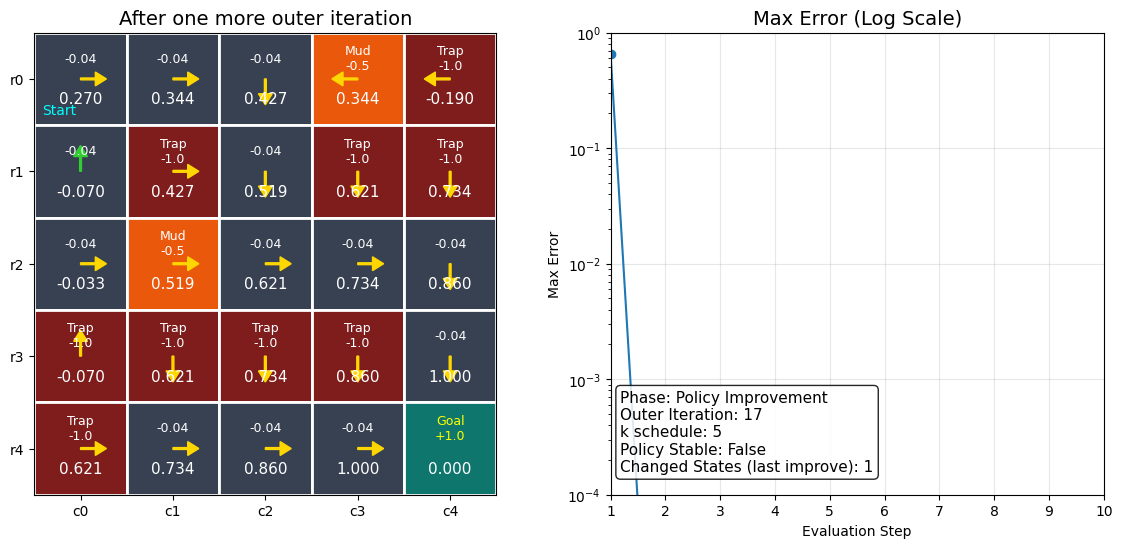

In [33]:

demo.run_one_outer_iteration(verbose=True)
demo.render(title="After one more outer iteration")
demo.show_tables()


## 9. Run all the way to convergence

If you do not want to click through every round manually, you can now run everything until the policy becomes stable.

A good study strategy is:

- manually inspect 1–2 rounds first
- then run this full convergence cell

That way, you understand both the **local changes** and the **final result**.


Reached max_outer=15, and the policy is still not marked as stable.


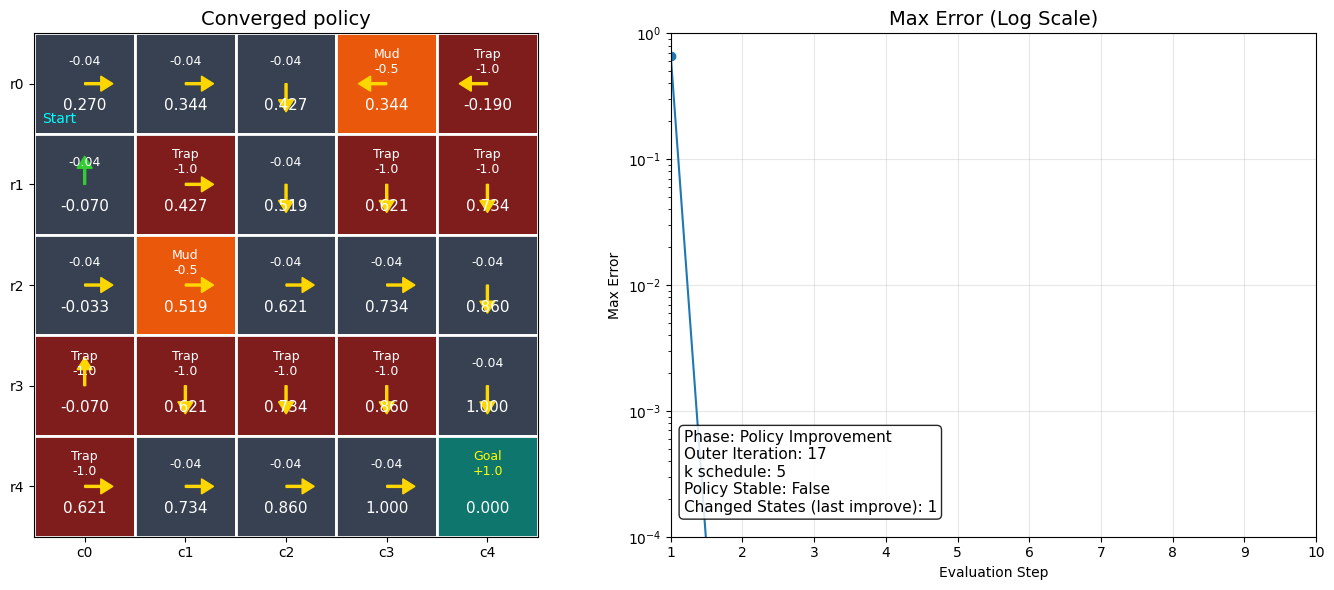

Current Value Table


,c0,c1,c2,c3,c4
r0,0.270,0.344,0.427,0.344,-0.190
r1,-0.070,0.427,0.519,0.621,0.734
r2,-0.033,0.519,0.621,0.734,0.860
r3,-0.070,0.621,0.734,0.860,1.000
r4,0.621,0.734,0.860,1.000,0.000


Current Policy Table


,c0,c1,c2,c3,c4
r0,→,→,↓,←,←
r1,↑,→,↓,↓,↓
r2,→,→,→,→,↓
r3,↑,↓,↓,↓,↓
r4,→,→,→,→,Goal


Iteration Summary


,iteration,k,eval_steps_done,last_max_diff,changed_states,stable
0,10,5,5,6.561000e-01,12,False
1,11,5,5,1.549682e-02,6,False
2,12,5,5,9.150717e-03,3,False
3,13,5,5,5.403407e-03,2,False
4,14,5,5,3.190658e-03,3,False
5,15,5,5,1.884051e-03,3,False
6,16,5,5,1.112514e-03,1,False
7,17,5,5,1.000000e-12,1,False


In [34]:

demo.run_to_convergence(max_outer=15, verbose=False)
demo.render(title="Converged policy")
demo.show_tables()


## 10. Let the agent follow the current or final policy

If the policy has already converged, this matches the final agent segment in the video.

If the policy is **not** stable yet, the notebook will warn you and label the figure as **Current Policy** instead of **Final Policy**.

It will:

- draw the path taken by the agent
- list the visited coordinates
- report the total reward
- tell you whether the agent reached the Goal


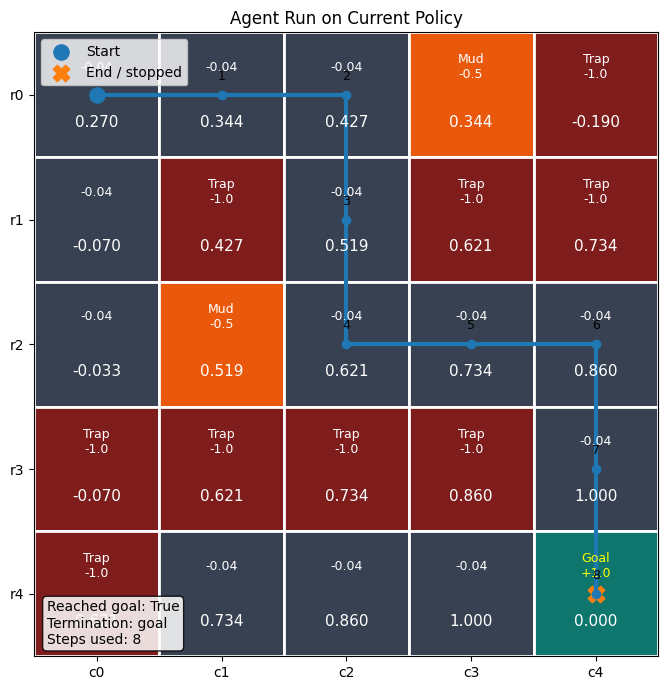

Agent run result:
{'path': [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 3), (2, 4), (3, 4), (4, 4)], 'total_reward': 0.72, 'hit_goal': True, 'steps_used': 8, 'loop_detected': False, 'termination_reason': 'goal'}


{'path': [(0, 0),
  (0, 1),
  (0, 2),
  (1, 2),
  (2, 2),
  (2, 3),
  (2, 4),
  (3, 4),
  (4, 4)],
 'total_reward': 0.72,
 'hit_goal': True,
 'steps_used': 8,
 'loop_detected': False,
 'termination_reason': 'goal'}

In [35]:

demo.plot_agent_run(max_steps=20)


## 11. Reset the experiment

If you want to replay the full process from the beginning, run the next cell.

It will:

- reset the values
- reset the random initial policy
- return the notebook to the same starting point as the video


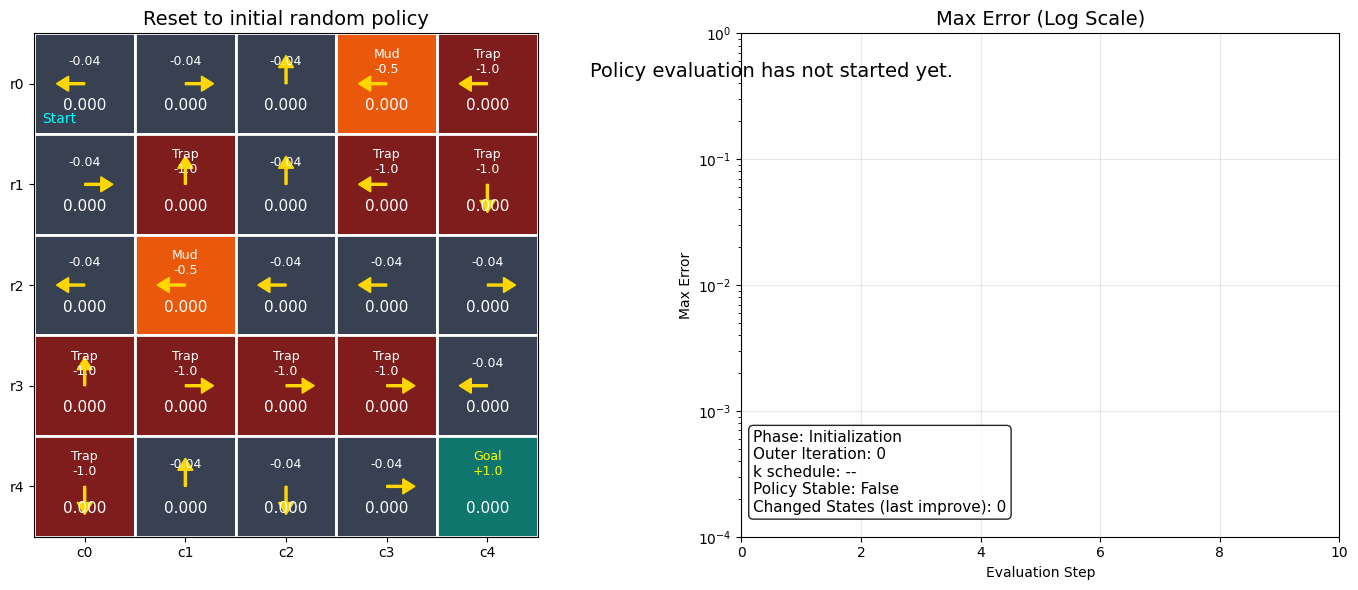

Current Value Table


,c0,c1,c2,c3,c4
r0,0.0,0.0,0.0,0.0,0.0
r1,0.0,0.0,0.0,0.0,0.0
r2,0.0,0.0,0.0,0.0,0.0
r3,0.0,0.0,0.0,0.0,0.0
r4,0.0,0.0,0.0,0.0,0.0


Current Policy Table


,c0,c1,c2,c3,c4
r0,←,→,↑,←,←
r1,→,↑,↑,←,↓
r2,←,←,←,←,→
r3,↑,→,→,→,←
r4,↓,↑,↓,→,Goal


In [36]:

demo.reset(seed=42)
demo.render(title="Reset to initial random policy")
demo.show_tables()


## 12. Suggested student exercises

### Exercise A: Change the discount factor
Try changing the initialization to:

```python
demo = PolicyIterationExplorer(gamma=0.7, seed=42)
```

Then ask:

- Does value information spread more slowly or more quickly?
- Does the final policy change?

### Exercise B: Change the rewards
Try changing some `-1.0` trap cells into `-0.2` or `-2.0`.

Then ask:

- Does the agent become more willing to pass near traps?
- Does the best path change?

### Exercise C: Track one state over time
Run this many times during the experiment:

```python
demo.inspect_state((2, 2))
```

Then compare how its four action values change from round to round.

### Exercise D: Compare fixed-`k` evaluation vs full evaluation
Extend this notebook so that in each outer iteration, evaluation does **not** stop after a fixed `k`.  
Instead, let it continue until `max_diff < 1e-4`.

Then compare:

- classic Policy Iteration
- Modified Policy Iteration (fixed `k`)

---

This notebook is not optimized for the fewest lines of code.  
It is optimized for **learning step by step**.
